In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

In [6]:
import sys
sys.path.append('..')

import models
import toolkit

importlib.reload(models)
importlib.reload(toolkit)

from models import *
from toolkit import *

In [7]:
model_kit = ModelKit()
stat_kit = StatKit()

In [8]:
df = pd.DataFrame({
    "Job Title": ["Engineer", "Engineer", "Nurse", "Nurse", "Pilot", "Pilot"],
    "Salary": [80, 82, 60, 62, 120, 118],
})
df

,Job Title,Salary
0,Engineer,80
1,Engineer,82
2,Nurse,60
3,Nurse,62
4,Pilot,120
5,Pilot,118


In [9]:
# Wrong approach: ordinal IDs for a categorical feature
# title_to_id = {t: i for i, t in enumerate(sorted(df["Job Title"].unique(), reverse=True))}
title_to_id = {"Nurse": 1, "Engineer": 2, "Pilot": 3}
x_bad = df["Job Title"].map(title_to_id).to_numpy(dtype=np.float64).astype(np.float64)
y = df["Salary"].to_numpy(dtype=np.float64)

bad_model = SimpleLinearRegression()
bad_model.train(x_bad, y.astype(np.float64))
b0_bad, b1_bad = bad_model.params()
y_bad = bad_model.predict(x_bad)

print("Mapping:", title_to_id)
print(f"Bad model: y = {b0_bad:.2f} + {b1_bad:.2f} * title_id")
print("Predictions for IDs [0, 1, 2]:", bad_model.predict(np.array([0, 1, 2], dtype=np.float64)))

Mapping: {'Nurse': 1, 'Engineer': 2, 'Pilot': 3}
Bad model: y = 29.00 + 29.00 * title_id
Predictions for IDs [0, 1, 2]: [29. 58. 87.]


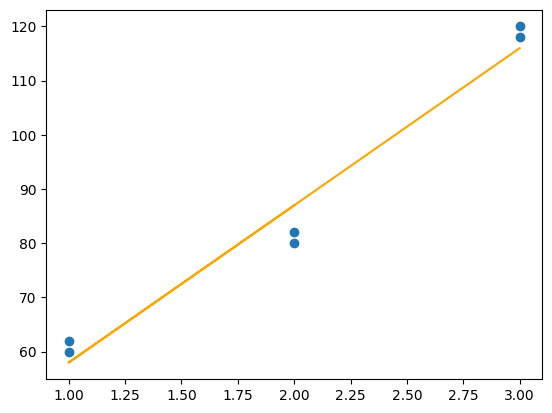

In [10]:
plt.scatter(x_bad, y)
plt.plot(x_bad, y_bad, color="orange")

In [11]:
# Correct approach: one-hot encode Job Title
X_df = pd.get_dummies(df["Job Title"], prefix="Job", drop_first=True, dtype=np.float64)
X = X_df.to_numpy(dtype=np.float64)
features = list(X.T)
y = df["Salary"].to_numpy(dtype=np.float64)

good_model = MultiLinearRegression()
good_model.train(features, y)

coef_table = pd.DataFrame({
    "Term": ["Intercept"] + list(X_df.columns),
    "Coefficient": good_model.theta,
})

print("One-hot columns:", list(X_df.columns))
coef_table

One-hot columns: ['Job_Nurse', 'Job_Pilot']


,Term,Coefficient
0,Intercept,81.0
1,Job_Nurse,-20.0
2,Job_Pilot,38.0


In [12]:
X, features

(array([[0., 0.],
        [0., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.]]),
 [array([0., 0., 1., 1., 0., 0.]), array([0., 0., 0., 0., 1., 1.])])

In [13]:
y_pred_good = good_model.predict(list(X.T))
mk = ModelKit()
print("R^2 (one-hot):", mk.r_squared(y_pred_good, y))

out = df.copy()
out["Pred_OneHot"] = y_pred_good
out

R^2 (one-hot): 0.9982748706152962


,Job Title,Salary,Pred_OneHot
0,Engineer,80,81.0
1,Engineer,82,81.0
2,Nurse,60,61.0
3,Nurse,62,61.0
4,Pilot,120,119.0
5,Pilot,118,119.0


### Coefficient meaning
- Intercept: mean salary of the dropped baseline title.
- Each one-hot coefficient: salary difference vs baseline, holding other features fixed.
- These are category offsets, not numeric slopes like years of experience.

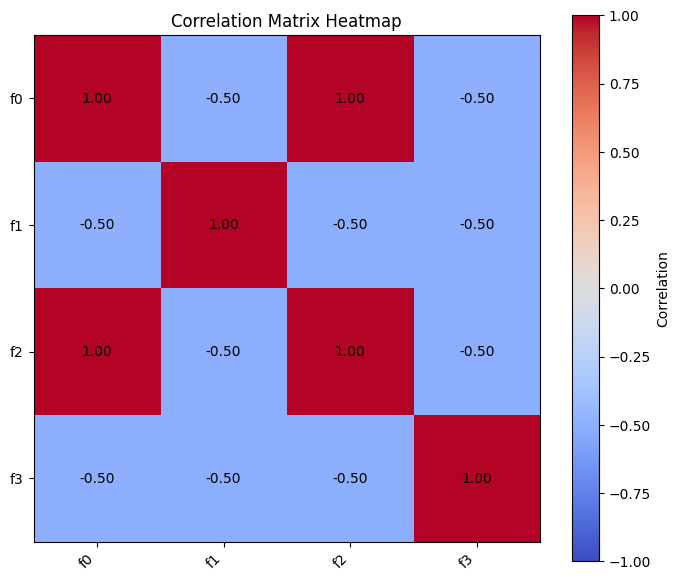

In [15]:
# matrix = np.array((
#     [1, 1, 3],
#     [1, 4, 6],
#     [1, 1, 3]
# ), dtype=np.float64)

f0 = np.array([1, 2, 1], dtype=np.float64)
f1 = np.array([1, 0, 0], dtype=np.float64)
f2 = np.array([0, 1, 0], dtype=np.float64)
f3 = np.array([0, 0, 1], dtype=np.float64)

matrix = stat_kit.corr_matrix([f0, f1, f2, f3])

# 2) Plot heatmap
plt.figure(figsize=(7, 6))
im = plt.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")

# 3) Axis labels
plt.xticks(range(4), ["f0", "f1", "f2", "f3"], rotation=45, ha="right")
plt.yticks(range(4), ["f0", "f1", "f2", "f3"])

# 4) Optional: write correlation values inside cells
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

## Reference Notes

- [near-linear-dependency.md](../notes/near-linear-dependency.md)